# Hough transform for circles with `skimage`


## Important note about probabilistic Hough for circles

`skimage` provides:

- `hough_line`
- `probabilistic_hough_line`
- `hough_circle`

but it does **not** provide a `probabilistic_hough_circle` function.

So unlike the quadrilateral notebook, there is **no true probabilistic circle Hough transform to add inside this library**.

In this notebook I therefore keep the standard circle Hough transform, print the results in a consistent peak format, and explicitly note that a direct probabilistic circle comparison is not available in `skimage`.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from skimage.draw import circle_perimeter_aa, line_aa
from skimage.feature import canny
from skimage.filters import gaussian
from skimage.transform import hough_circle, hough_circle_peaks

plt.rcParams['figure.dpi'] = 120

H = W = 180


def draw_circle_edge(img, center, radius, value=1.0):
    rr, cc, val = circle_perimeter_aa(int(center[0]), int(center[1]), int(radius))
    valid = (rr >= 0) & (rr < img.shape[0]) & (cc >= 0) & (cc < img.shape[1])
    img[rr[valid], cc[valid]] = np.maximum(img[rr[valid], cc[valid]], value * val[valid])


def draw_segment(img, p0, p1, value=1.0):
    rr, cc, val = line_aa(int(round(p0[0])), int(round(p0[1])), int(round(p1[0])), int(round(p1[1])))
    valid = (rr >= 0) & (rr < img.shape[0]) & (cc >= 0) & (cc < img.shape[1])
    img[rr[valid], cc[valid]] = np.maximum(img[rr[valid], cc[valid]], value * val[valid])


def overlay_circles(ax, centers_x, centers_y, radii, scores=None, max_show=None):
    if max_show is None:
        max_show = len(radii)
    colors = plt.cm.tab10(np.linspace(0, 1, max_show))
    for i, (cx, cy, radius, color) in enumerate(zip(centers_x[:max_show], centers_y[:max_show], radii[:max_show], colors), start=1):
        patch = Circle((cx, cy), radius, fill=False, ec=color, lw=2)
        ax.add_patch(patch)
        text = f'{i}: r={radius}' if scores is None else f'{i}: r={radius}, score={scores[i-1]:.3f}'
        ax.text(cx + 3, cy + 3, text, color=color, fontsize=8)


def print_circle_peaks(title, accums, centers_x, centers_y, radii):
    print(title)
    for i, (accum, cx, cy, radius) in enumerate(zip(accums, centers_x, centers_y, radii), start=1):
        print(f'  {i:02d}: score={float(accum):.3f}, center=({cx}, {cy}), radius={radius}')
    print()


**Important parameters used in this notebook**

- `canny(..., sigma, low_threshold, high_threshold)`: controls which edge pixels are kept before circle voting.
- `hough_circle(edges, radii, normalize=True)`: computes one Hough space for each radius in `radii`.
- `radii`: this is the key search space. If you know the radius, use a narrow set. If not, search a range.
- `normalize=True`: helps compare radii more fairly.
- `hough_circle_peaks(...)`: extracts the strongest circle candidates from the Hough spaces.
- `min_xdistance` and `min_ydistance`: reduce near-duplicate center detections.


## Example 1: known radius

In this first example, we know the target circle radius in advance.

That means the algorithm only needs to search for the **center** of a circle of radius 32.

I also add a couple of weak line distractors so the image is not perfectly clean.


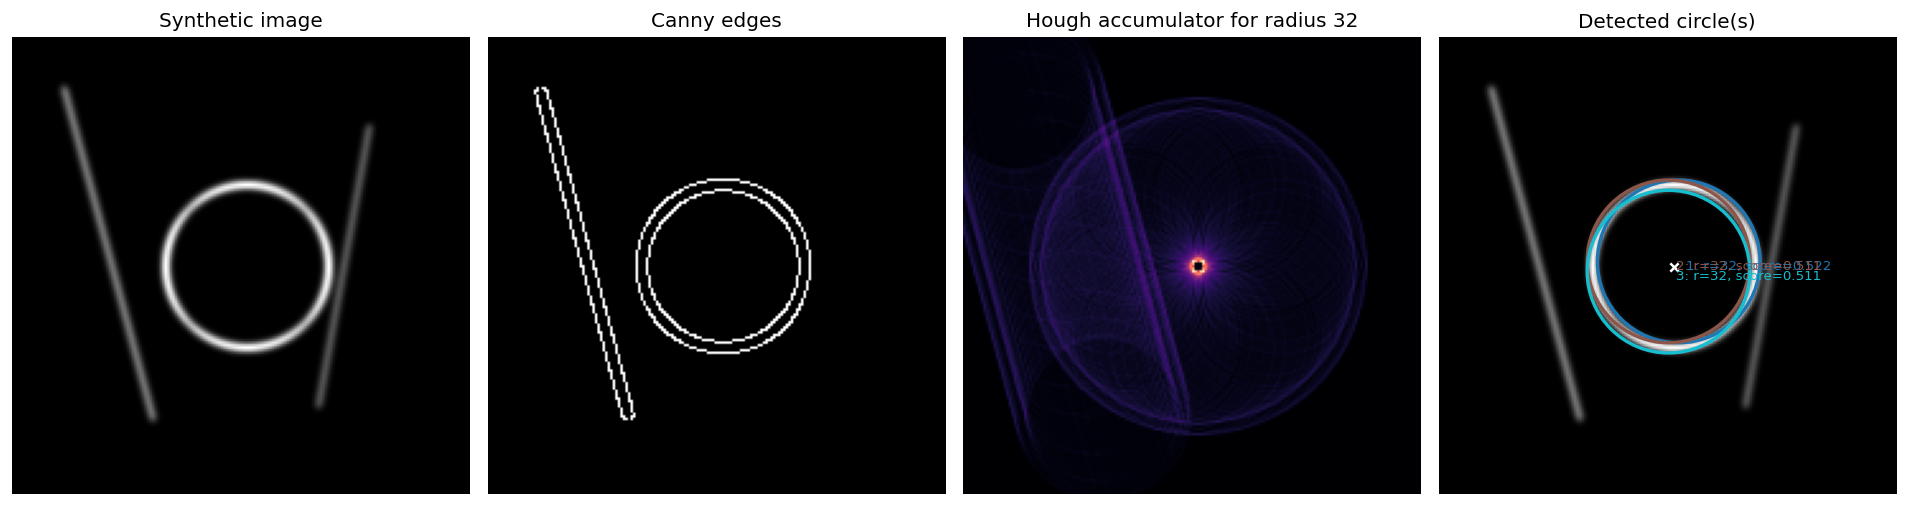

Top peaks for the known-radius case:
  01: score=0.522, center=(94, 88), radius=32
  02: score=0.511, center=(90, 88), radius=32
  03: score=0.511, center=(90, 92), radius=32



In [5]:
img1 = np.zeros((H, W), dtype=float)
true_center1 = (90, 92)
known_radius = 32

draw_circle_edge(img1, true_center1, known_radius, value=0.55)
draw_segment(img1, (20, 20), (150, 55), value=0.25)
draw_segment(img1, (35, 140), (145, 120), value=0.18)

img1 = gaussian(img1, sigma=1.4, preserve_range=True)
edges1 = canny(img1, sigma=1.6, low_threshold=0.03, high_threshold=0.08)

radii_known = np.array([known_radius])
hspaces1 = hough_circle(edges1, radii_known, normalize=True)
accums1, cx1, cy1, rad1 = hough_circle_peaks(hspaces1, radii_known, total_num_peaks=3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Synthetic image')
axes[0].set_axis_off()

axes[1].imshow(edges1, cmap='gray')
axes[1].set_title('Canny edges')
axes[1].set_axis_off()

axes[2].imshow(hspaces1[0], cmap='magma')
axes[2].set_title(f'Hough accumulator for radius {known_radius}')
axes[2].set_axis_off()

axes[3].imshow(img1, cmap='gray')
axes[3].set_title('Detected circle(s)')
overlay_circles(axes[3], cx1, cy1, rad1, scores=accums1, max_show=3)
axes[3].scatter([true_center1[1]], [true_center1[0]], c='white', s=25, marker='x')
axes[3].set_axis_off()

plt.tight_layout()
plt.show()

print_circle_peaks('Top peaks for the known-radius case:', accums1, cx1, cy1, rad1)


**Why this case is easier**

- `radii_known = [32]`: only one radius is tested, so the search is much smaller.
- `total_num_peaks=3`: returns a few center candidates for that fixed radius.

This is the circle analogue of reducing the search space before detection.


## Example 2: unknown radius

Now we do **not** know the radius.

The image contains:

- one stronger smaller circle
- one weaker larger circle
- diagonal line clutter

So the detector must search for both the center and the radius.


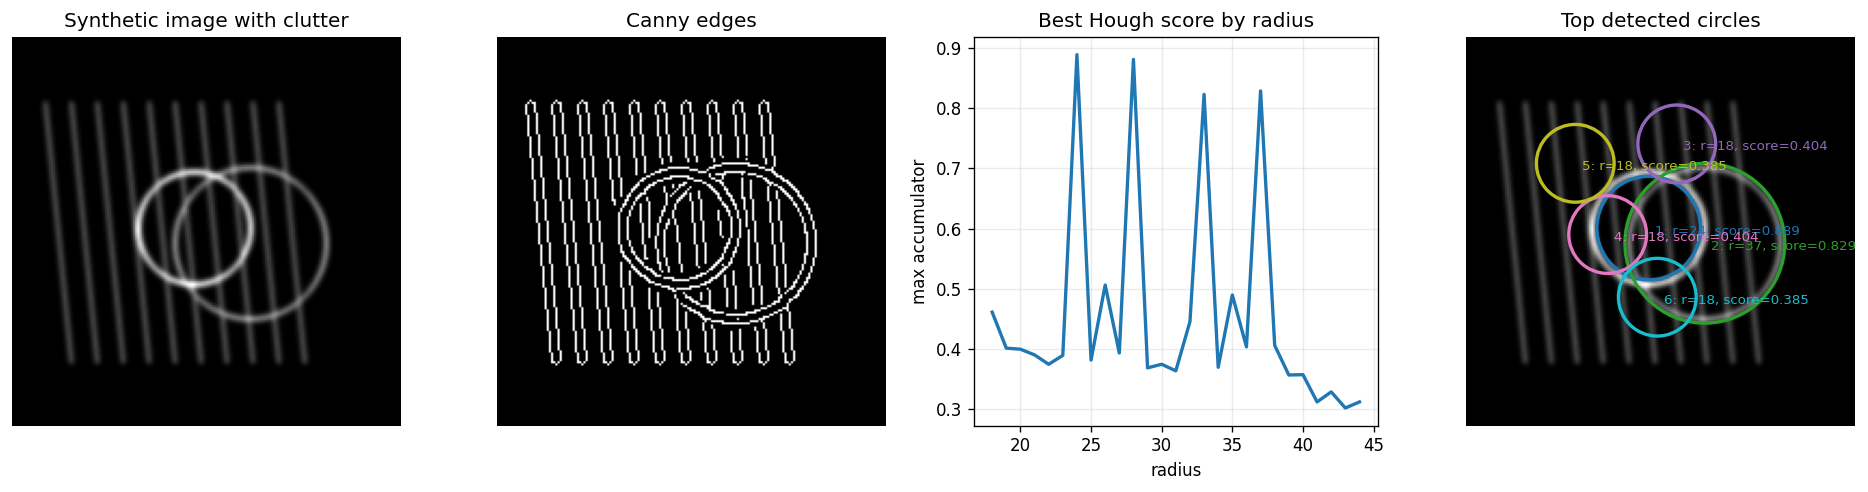

Top peaks for the unknown-radius case:
  01: score=0.889, center=(84, 88), radius=24
  02: score=0.829, center=(110, 95), radius=37
  03: score=0.404, center=(97, 49), radius=18
  04: score=0.404, center=(65, 91), radius=18
  05: score=0.385, center=(50, 58), radius=18
  06: score=0.385, center=(88, 120), radius=18



In [6]:
img2 = np.zeros((H, W), dtype=float)

draw_circle_edge(img2, (88, 84), 26, value=0.75)
draw_circle_edge(img2, (95, 110), 35, value=0.45)

for shift in range(15, 135, 12):
    draw_segment(img2, (30, shift), (150, shift + 12), value=0.25)

img2 = gaussian(img2, sigma=1.3, preserve_range=True)
edges2 = canny(img2, sigma=1.4, low_threshold=0.03, high_threshold=0.09)

radii_unknown = np.arange(18, 45)
hspaces2 = hough_circle(edges2, radii_unknown, normalize=True)
radius_scores = hspaces2.max(axis=(1, 2))

accums2, cx2, cy2, rad2 = hough_circle_peaks(
    hspaces2,
    radii_unknown,
    min_xdistance=18,
    min_ydistance=18,
    total_num_peaks=6,
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Synthetic image with clutter')
axes[0].set_axis_off()

axes[1].imshow(edges2, cmap='gray')
axes[1].set_title('Canny edges')
axes[1].set_axis_off()

axes[2].plot(radii_unknown, radius_scores, color='tab:blue', lw=2)
axes[2].set_title('Best Hough score by radius')
axes[2].set_xlabel('radius')
axes[2].set_ylabel('max accumulator')
axes[2].grid(alpha=0.25)

axes[3].imshow(img2, cmap='gray')
axes[3].set_title('Top detected circles')
overlay_circles(axes[3], cx2, cy2, rad2, scores=accums2, max_show=6)
axes[3].set_axis_off()

plt.tight_layout()
plt.show()

print_circle_peaks('Top peaks for the unknown-radius case:', accums2, cx2, cy2, rad2)


**Why this case is harder**

- `radii_unknown = np.arange(18, 45)`: the transform must search many radii.
- `radius_scores = hspaces2.max(axis=(1, 2))`: this summarizes how strongly each radius is supported.
- `min_xdistance=18` and `min_ydistance=18`: reduce near-duplicate center detections.

The top circles are still printed in the same peak format, but unlike the quadrilateral notebook, there is no `probabilistic_hough_circle` result to print next to them in `skimage`.


## Final takeaway

- When the radius is **known**, Hough circle detection is simpler because only the center must be found.
- When the radius is **unknown**, the search space is larger and clutter creates extra candidates.
- `skimage` offers a probabilistic Hough transform only for **lines**, not for **circles**.

If you want a stronger built-in circle detector to compare later, the main libraries worth checking are:

- **OpenCV** with `HoughCircles` using the Hough gradient method
- **MATLAB** with `imfindcircles`, which offers circular Hough variants such as `PhaseCode` and `TwoStage`

These are better known circle-detection implementations, but they are still **not** a probabilistic circle Hough transform in the same sense as line PHT.
